# PaySim — EDA & Tiền xử lý dữ liệu

Notebook này dùng để:
- Đọc dữ liệu `data/paysim.csv`
- In thống kê số dòng, tỷ lệ gian lận
- Vẽ biểu đồ so sánh **fraud** vs **non-fraud**
- Khai thác thêm nhiều thông tin (type, amount, step, balance anomalies, correlation)
- Tiền xử lý nhẹ (feature engineering) và lưu ra file (tuỳ chọn)

Gợi ý: Dataset PaySim khá lớn (hàng triệu dòng). Notebook có chế độ **chunk** và **sample** để chạy mượt.

## 0) Cài thư viện (nếu máy bạn thiếu)

Nếu bạn đang chạy notebook ở môi trường chưa có `pandas/matplotlib/seaborn`, chạy cell này một lần.

In [ ]:
# Nếu cần thì bỏ comment để cài nhanh
# pip install -U pandas numpy matplotlib seaborn pyarrow

## 1) Import + cấu hình

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

project_root = Path.cwd()
candidates = [
    project_root / "data" / "paysim.csv",
    project_root.parent / "data" / "paysim.csv",
]
DATA_PATH = next((p for p in candidates if p.exists()), candidates[0])
print("Working dir:", project_root.resolve())
print("Using data:", DATA_PATH.resolve())
assert DATA_PATH.exists(), f"Không thấy file: {DATA_PATH.resolve()}"

Working dir: C:\Users\ACER\OneDrive\Desktop\BigData\BigDataFraudDetection\notebooks
Using data: C:\Users\ACER\OneDrive\Desktop\BigData\BigDataFraudDetection\data\paysim.csv


## 2) Đọc dữ liệu (chunk hoặc full)

- `READ_FULL=False`: chỉ đọc sample để vẽ biểu đồ nhanh
- `READ_FULL=True`: đọc toàn bộ (tuỳ RAM máy bạn)

In [2]:
READ_FULL = False
SAMPLE_ROWS = 300_000  # tăng/giảm tuỳ máy

usecols = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
]

dtypes = {
    "step": "int32",
    "type": "category",
    "amount": "float64",
    "nameOrig": "string",
    "oldbalanceOrg": "float64",
    "newbalanceOrig": "float64",
    "nameDest": "string",
    "oldbalanceDest": "float64",
    "newbalanceDest": "float64",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

if READ_FULL:
    df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes)
else:
    df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes, nrows=SAMPLE_ROWS)

df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3) Thông tin tổng quan

In [3]:
print("Rows:", len(df))
print("Columns:", df.shape[1])
display(df.dtypes)
df.describe(include="all").T.head(30)

Rows: 300000
Columns: 11


step                 int32
type              category
amount             float64
nameOrig            string
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest            string
oldbalanceDest     float64
newbalanceDest     float64
isFraud               int8
isFlaggedFraud        int8
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,300000.0,NaN,NaN,NaN,11.44147,2.639757,1.0,10.0,12.0,14.0,15.0
type,300000,5,CASH_OUT,105401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,300000.0,NaN,NaN,NaN,176170.826423,301605.500911,0.3,12741.25,77699.525,231478.9475,10000000.0
nameOrig,300000,299982,C199116739,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,300000.0,NaN,NaN,NaN,885567.577106,2849254.42312,0.0,0.0,18569.0,183687.475,38939424.03
newbalanceOrig,300000.0,NaN,NaN,NaN,904281.974529,2886694.198057,0.0,0.0,0.0,221479.7075,38946233.02
nameDest,300000,134668,C985934102,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,300000.0,NaN,NaN,NaN,977452.521524,2369811.436715,0.0,0.0,86166.865,857155.185,41338441.34
newbalanceDest,300000.0,NaN,NaN,NaN,1196708.508103,2594206.736046,0.0,0.0,190822.025,1238132.06,41383645.15
isFraud,300000.0,NaN,NaN,NaN,0.000603,0.024555,0.0,0.0,0.0,0.0,1.0


In [4]:
# Missing / duplicates
missing = df.isna().sum().sort_values(ascending=False)
dup_count = df.duplicated().sum()
display(missing[missing > 0])
print("Duplicated rows:", dup_count)

Series([], dtype: int64)

Duplicated rows: 0


## 4) Tổng số dòng fraud vs non-fraud

PaySim dùng cột `isFraud` (0/1). Nếu bạn đang dùng data khác có `is_fraud` thì có thể đổi `LABEL_COL`.

In [5]:
LABEL_COL = "isFraud" if "isFraud" in df.columns else ("is_fraud" if "is_fraud" in df.columns else None)
assert LABEL_COL is not None, "Không tìm thấy cột nhãn fraud (isFraud / is_fraud)"

fraud_counts = df[LABEL_COL].value_counts(dropna=False).sort_index()
fraud_total = int(fraud_counts.get(1, 0))
non_fraud_total = int(fraud_counts.get(0, 0))
total = int(len(df))

print(f"Total rows: {total:,}")
print(f"Non-fraud (0): {non_fraud_total:,}")
print(f"Fraud (1): {fraud_total:,}")
print(f"Fraud rate: {fraud_total/total*100:.4f}%")

fraud_counts

Total rows: 300,000
Non-fraud (0): 299,819
Fraud (1): 181
Fraud rate: 0.0603%


isFraud
0    299819
1       181
Name: count, dtype: int64

### Biểu đồ chênh lệch fraud vs non-fraud

C:\Users\ACER\AppData\Local\Temp\ipykernel_11136\2337409381.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


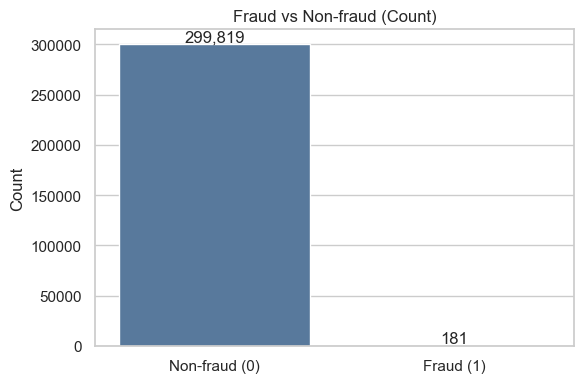

C:\Users\ACER\AppData\Local\Temp\ipykernel_11136\2337409381.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


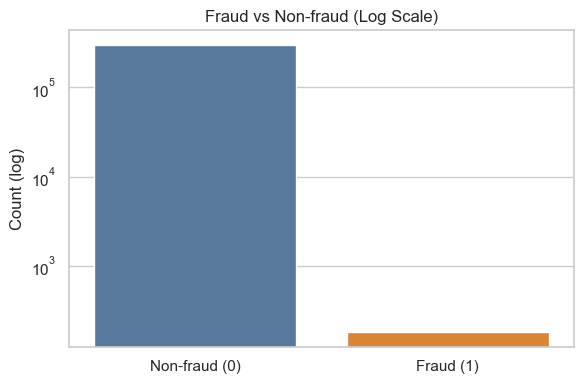

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=["Non-fraud (0)", "Fraud (1)"],
    y=[non_fraud_total, fraud_total],
    palette=["#4C78A8", "#F58518"],
)
ax.set_title("Fraud vs Non-fraud (Count)")
ax.set_ylabel("Count")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=["Non-fraud (0)", "Fraud (1)"],
    y=[non_fraud_total, fraud_total],
    palette=["#4C78A8", "#F58518"],
)
ax.set_yscale("log")
ax.set_title("Fraud vs Non-fraud (Log Scale)")
ax.set_ylabel("Count (log)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 5) Phân phối theo loại giao dịch (type)

PaySim thường fraud tập trung ở `TRANSFER` và `CASH_OUT`.

type
CASH_OUT    105401
PAYMENT     104056
CASH_IN      63408
TRANSFER     24905
DEBIT         2230
Name: count, dtype: int64

C:\Users\ACER\AppData\Local\Temp\ipykernel_11136\684517921.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="type", order=type_counts.index, palette="viridis")


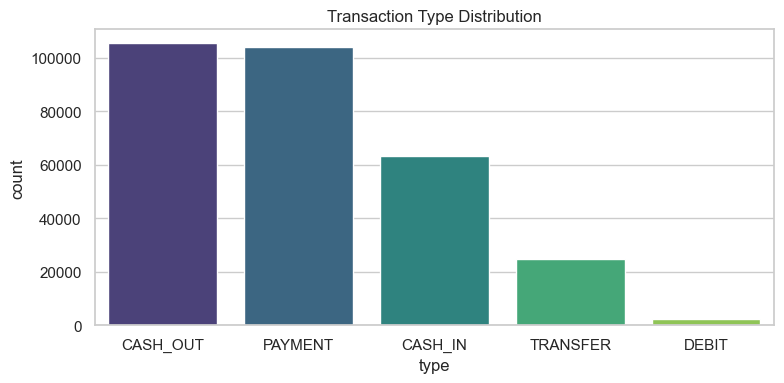

In [7]:
type_counts = df["type"].value_counts()
display(type_counts)

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="type", order=type_counts.index, palette="viridis")
ax.set_title("Transaction Type Distribution")
ax.set_xlabel("type")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

,count,fraud_count,fraud_rate
type,,,
TRANSFER,24905,88,0.003533
CASH_OUT,105401,93,0.000882
CASH_IN,63408,0,0.000000
DEBIT,2230,0,0.000000
PAYMENT,104056,0,0.000000


C:\Users\ACER\AppData\Local\Temp\ipykernel_11136\1542662215.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fraud_by_type.reset_index(), x="type", y="fraud_rate", palette="magma")


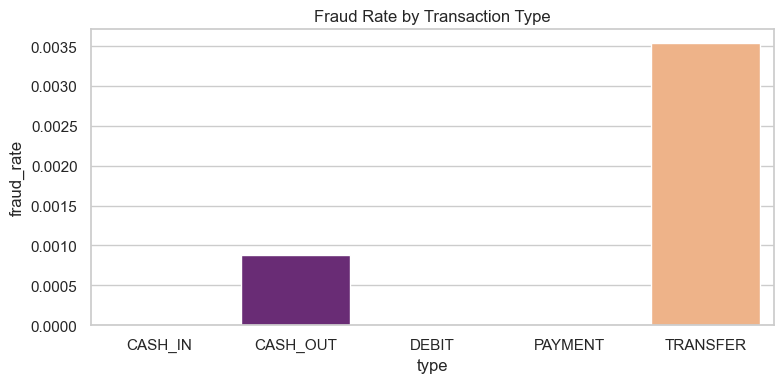

In [8]:
fraud_by_type = df.groupby("type")[LABEL_COL].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)
fraud_by_type.rename(columns={"sum": "fraud_count", "mean": "fraud_rate"}, inplace=True)
display(fraud_by_type)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=fraud_by_type.reset_index(), x="type", y="fraud_rate", palette="magma")
ax.set_title("Fraud Rate by Transaction Type")
ax.set_xlabel("type")
ax.set_ylabel("fraud_rate")
plt.tight_layout()
plt.show()

## 6) Amount: so sánh fraud vs non-fraud

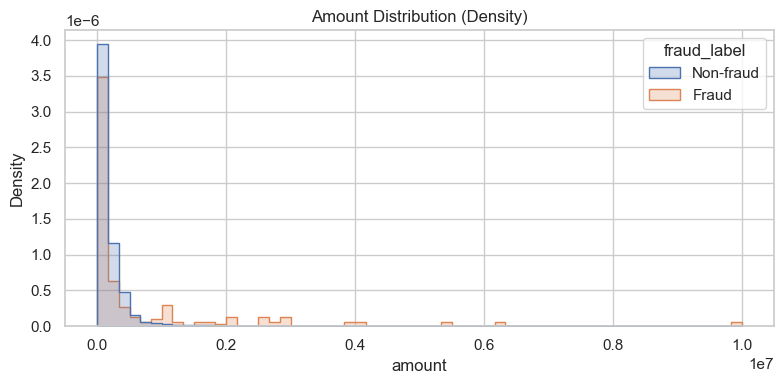

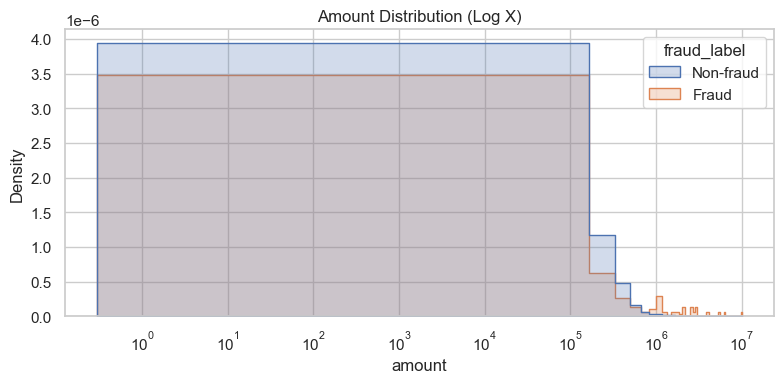

In [9]:
df_plot = df.copy()
df_plot["fraud_label"] = np.where(df_plot[LABEL_COL] == 1, "Fraud", "Non-fraud")

plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_plot,
    x="amount",
    hue="fraud_label",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Amount Distribution (Density)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_plot,
    x="amount",
    hue="fraud_label",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
)
plt.xscale("log")
plt.title("Amount Distribution (Log X)")
plt.tight_layout()
plt.show()

## 7) Feature engineering (tiền xử lý nhẹ)

Tạo thêm một số feature thường dùng trong PaySim:
- `balance_diff_orig` = newbalanceOrig - oldbalanceOrg
- `balance_diff_dest` = newbalanceDest - oldbalanceDest
- `amount_to_oldbalance_ratio`
- `zero_balance_after` (newbalanceOrig == 0 nhưng oldbalanceOrg > 0)

Mục tiêu là có data “giàu” hơn để phân tích/training.

In [10]:
df_fe = df.copy()

df_fe["balance_diff_orig"] = df_fe["newbalanceOrig"] - df_fe["oldbalanceOrg"]
df_fe["balance_diff_dest"] = df_fe["newbalanceDest"] - df_fe["oldbalanceDest"]

df_fe["amount_to_oldbalance_ratio"] = np.where(
    df_fe["oldbalanceOrg"] > 0,
    df_fe["amount"] / df_fe["oldbalanceOrg"],
    0.0,
)

df_fe["zero_balance_after"] = ((df_fe["newbalanceOrig"] == 0) & (df_fe["oldbalanceOrg"] > 0)).astype("int8")

# Sanity: thay inf bằng NaN rồi fill 0
df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
df_fe.fillna(0, inplace=True)

df_fe[["balance_diff_orig", "balance_diff_dest", "amount_to_oldbalance_ratio", "zero_balance_after"]].describe().T

,count,mean,std,min,25%,50%,75%,max
balance_diff_orig,300000.0,18714.397423,130260.155004,-10000000.00,-10787.9625,0.000000,0.000000,1289407.91
balance_diff_dest,300000.0,219255.986579,730217.698585,-13060826.21,0.0000,0.000000,248790.802500,38892049.56
amount_to_oldbalance_ratio,300000.0,78.352406,2140.710742,0.00,0.0000,0.054658,1.714192,475620.28
zero_balance_after,300000.0,0.223580,0.416644,0.00,0.0000,0.000000,0.000000,1.00


### So sánh một feature quan trọng: amount_to_oldbalance_ratio

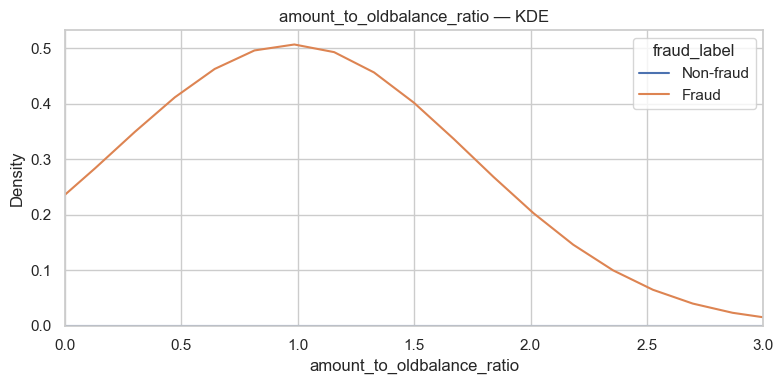

In [11]:
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=df_fe.assign(fraud_label=np.where(df_fe[LABEL_COL] == 1, "Fraud", "Non-fraud")),
    x="amount_to_oldbalance_ratio",
    hue="fraud_label",
    common_norm=False,
)
plt.title("amount_to_oldbalance_ratio — KDE")
plt.xlim(0, 3)
plt.tight_layout()
plt.show()

## 8) Thống kê theo `step` (thời gian)

`step` là thời điểm giả lập (giờ) trong PaySim.

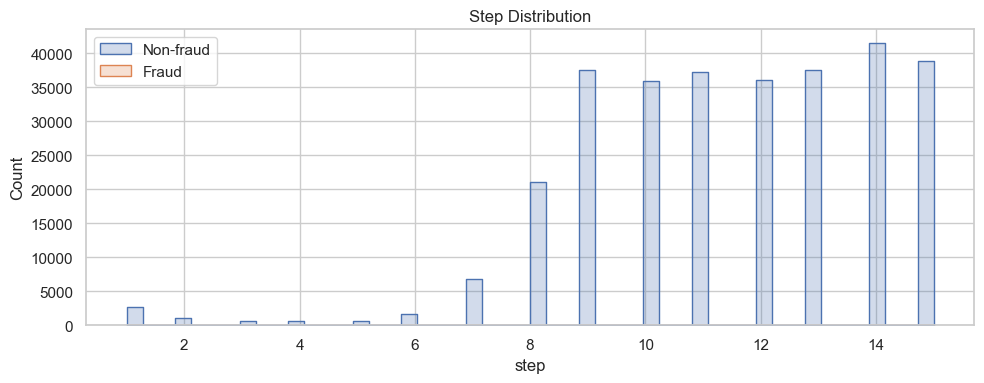

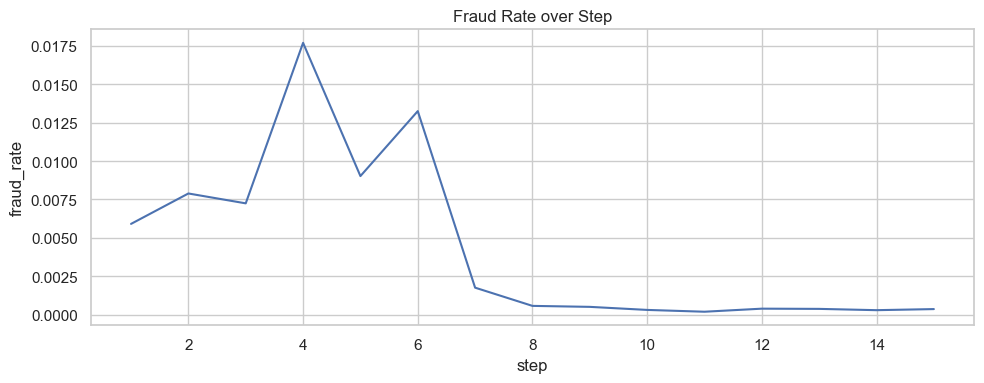

In [13]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="step", bins=50, hue=np.where(df[LABEL_COL] == 1, "Fraud", "Non-fraud"), element="step")
plt.title("Step Distribution")
plt.tight_layout()
plt.show()

fraud_by_step = df.groupby("step")[LABEL_COL].mean().reset_index(name="fraud_rate")
plt.figure(figsize=(10, 4))
sns.lineplot(data=fraud_by_step, x="step", y="fraud_rate")
plt.title("Fraud Rate over Step")
plt.tight_layout()
plt.show()

## 9) Chunk stats trên toàn bộ file (không cần load full)

Cell này đọc theo chunks để tính **tổng fraud/non-fraud trên toàn bộ dataset** mà ít tốn RAM.

In [14]:
RUN_CHUNK_STATS = True
CHUNK_SIZE = 1_000_000

if RUN_CHUNK_STATS:
    totals = {0: 0, 1: 0}
    type_totals = {}
    rows = 0

    for chunk in pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes, chunksize=CHUNK_SIZE):
        rows += len(chunk)
        vc = chunk["isFraud"].value_counts()
        totals[0] += int(vc.get(0, 0))
        totals[1] += int(vc.get(1, 0))

        tc = chunk["type"].value_counts()
        for k, v in tc.items():
            type_totals[k] = type_totals.get(k, 0) + int(v)

    print(f"[FULL FILE] Total rows: {rows:,}")
    print(f"[FULL FILE] Non-fraud (0): {totals[0]:,}")
    print(f"[FULL FILE] Fraud (1): {totals[1]:,}")
    print(f"[FULL FILE] Fraud rate: {totals[1]/rows*100:.4f}%")

    display(pd.Series(type_totals).sort_values(ascending=False))

[FULL FILE] Total rows: 6,362,620
[FULL FILE] Non-fraud (0): 6,354,407
[FULL FILE] Fraud (1): 8,213
[FULL FILE] Fraud rate: 0.1291%


CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
dtype: int64

## 10) Lưu file đã tiền xử lý (tuỳ chọn)

Nếu bạn muốn dùng cho training/analytics nhanh hơn:
- Lưu parquet: `data/paysim_preprocessed.parquet`
- Hoặc lưu CSV sample: `data/paysim_preprocessed_sample.csv`

In [15]:
SAVE_OUTPUT = False
OUT_PARQUET = Path("data/paysim_preprocessed.parquet")
OUT_SAMPLE = Path("data/paysim_preprocessed_sample.csv")

if SAVE_OUTPUT:
    try:
        df_fe.to_parquet(OUT_PARQUET, index=False)
        print("Saved:", OUT_PARQUET.resolve())
    except Exception as e:
        print("Parquet save failed (cần pyarrow):", e)

    df_fe.sample(min(len(df_fe), 200_000), random_state=42).to_csv(OUT_SAMPLE, index=False)
    print("Saved:", OUT_SAMPLE.resolve())